# ML-06 — Signal Audit: Do the Flags Hold?

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

I first inspected the distributions of the fields that will be used in the signal tests. The traffic and rate variables are strongly right-skewed: most records have relatively small values, while a small number of records have extremely large impressions, clicks, CTR, or engagement values.

For example, impressions and clicks have means substantially above their medians, which indicates that raw averages can be dominated by a small number of high-traffic records. CTR and engagement also contain many zero values. For the following signal tests, I therefore use visible sample sizes, grouped medians, weighted rates, rank-based comparisons, or log-transformed traffic values instead of relying only on raw Pearson correlations.

Dataset shape: (30000, 44)
Fields inspected: 6
Total missing values in inspected fields: 0


,count,mean,median,p75,p90,p95,p99,max,missing_pct,zero_pct,skewness
impressions_90d,30000.0,5200.37,731.00,3615.25,12136.40,22996.50,73505.83,517715.0,0.0,0.00,11.38
clicks_90d,30000.0,16.10,1.00,7.00,32.00,69.05,253.01,4178.0,0.0,44.01,18.35
ctr,30000.0,0.51,0.07,0.29,0.65,1.09,8.33,100.0,0.0,44.04,17.44
avg_position,30000.0,16.34,10.80,22.30,36.80,48.20,69.90,245.0,0.0,4.02,1.98
engagement_rate,30000.0,2.53,0.00,1.35,6.94,12.50,33.33,100.0,0.0,72.10,7.22
days_since_last_update,30000.0,46.10,20.00,104.00,104.00,104.00,106.00,373.0,0.0,0.00,1.16


,field,mean,median,p99,maximum,skewness,mean_to_median_ratio,heavy_tail_observed
0,impressions_90d,5200.37,731.00,73505.83,517715.0,11.38,7.11,True
1,clicks_90d,16.10,1.00,253.01,4178.0,18.35,16.10,True
2,ctr,0.51,0.07,8.33,100.0,17.44,7.30,True
3,avg_position,16.34,10.80,69.90,245.0,1.98,1.51,True
4,engagement_rate,2.53,0.00,33.33,100.0,7.22,NaN,True
5,days_since_last_update,46.10,20.00,106.00,373.0,1.16,2.30,True


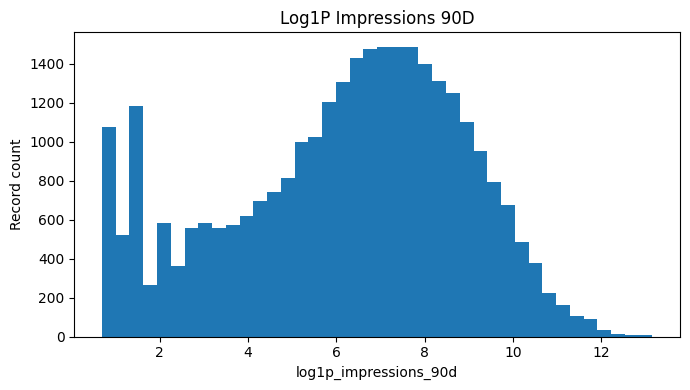

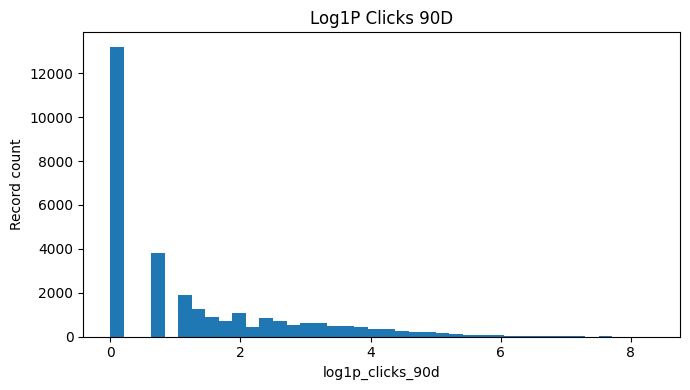

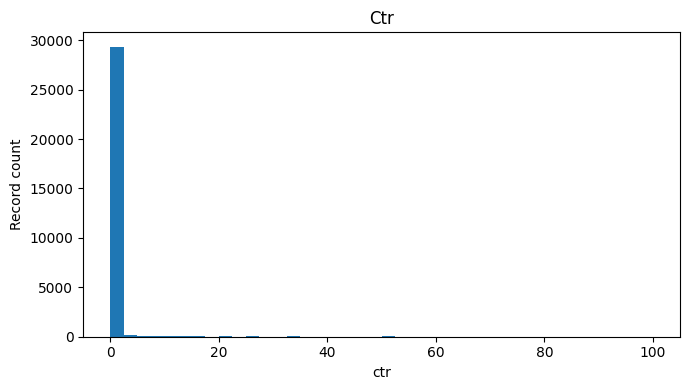

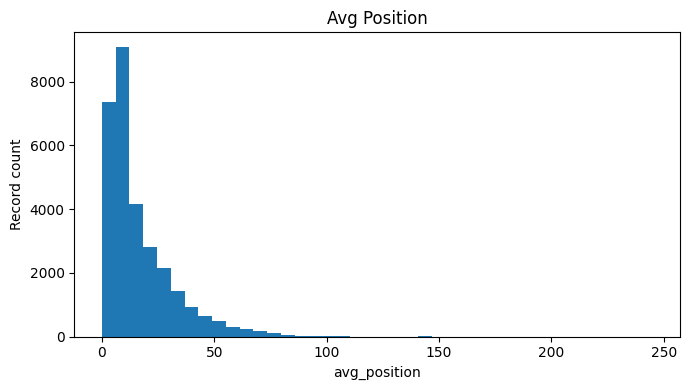

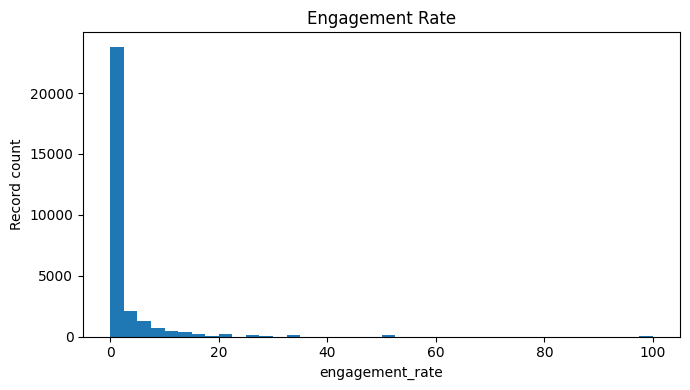

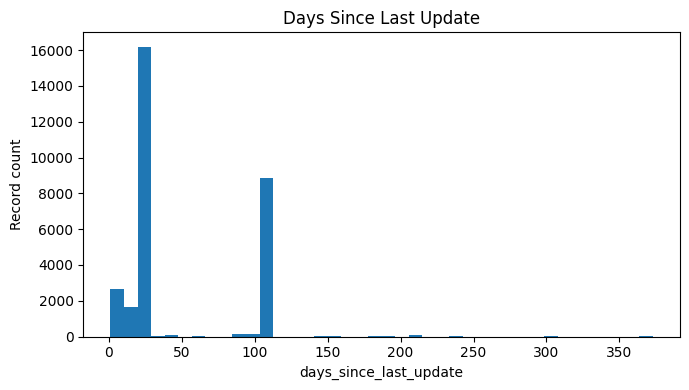

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "muhammetalicvs-prog/flyrank-ml/main/"
    "data/raw/content_refresh_anonymized.csv"
)

df = pd.read_csv(DATA_URL)

key_fields = [
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "avg_position",
    "engagement_rate",
    "days_since_last_update",
]

missing_fields = sorted(set(key_fields) - set(df.columns))
assert missing_fields == []

distribution_summary = (
    df[key_fields]
    .describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .T
    .rename(
        columns={
            "50%": "median",
            "75%": "p75",
            "90%": "p90",
            "95%": "p95",
            "99%": "p99",
        }
    )
)

distribution_summary["missing_pct"] = (
    df[key_fields].isna().mean().mul(100)
)

distribution_summary["zero_pct"] = (
    df[key_fields].eq(0).mean().mul(100)
)

distribution_summary["skewness"] = (
    df[key_fields].skew()
)

distribution_summary = distribution_summary[
    [
        "count",
        "mean",
        "median",
        "p75",
        "p90",
        "p95",
        "p99",
        "max",
        "missing_pct",
        "zero_pct",
        "skewness",
    ]
].round(2)

print("Dataset shape:", df.shape)
print("Fields inspected:", len(key_fields))
print(
    "Total missing values in inspected fields:",
    int(df[key_fields].isna().sum().sum()),
)

display(distribution_summary)

heavy_tail_check = pd.DataFrame(
    {
        "field": key_fields,
        "mean": [
            df[column].mean()
            for column in key_fields
        ],
        "median": [
            df[column].median()
            for column in key_fields
        ],
        "p99": [
            df[column].quantile(0.99)
            for column in key_fields
        ],
        "maximum": [
            df[column].max()
            for column in key_fields
        ],
        "skewness": [
            df[column].skew()
            for column in key_fields
        ],
    }
)

heavy_tail_check["mean_to_median_ratio"] = (
    heavy_tail_check["mean"]
    .div(
        heavy_tail_check["median"]
        .replace(0, np.nan)
    )
)

heavy_tail_check["heavy_tail_observed"] = (
    (heavy_tail_check["skewness"] > 1)
    | (
        heavy_tail_check["maximum"]
        > heavy_tail_check["p99"] * 2
    )
)

heavy_tail_check = heavy_tail_check.round(2)

display(heavy_tail_check)

plot_frame = pd.DataFrame(
    {
        "log1p_impressions_90d": np.log1p(
            df["impressions_90d"].clip(lower=0)
        ),
        "log1p_clicks_90d": np.log1p(
            df["clicks_90d"].clip(lower=0)
        ),
        "ctr": df["ctr"],
        "avg_position": df["avg_position"],
        "engagement_rate": df["engagement_rate"],
        "days_since_last_update": (
            df["days_since_last_update"]
        ),
    }
)

for column in plot_frame.columns:
    plt.figure(figsize=(7, 4))
    plt.hist(
        plot_frame[column].dropna(),
        bins=40,
    )
    plt.title(
        column.replace("_", " ").title()
    )
    plt.xlabel(column)
    plt.ylabel("Record count")
    plt.tight_layout()
    plt.show()

assert len(df) == 30000
assert distribution_summary.shape[0] == len(key_fields)

## 2. Signal test #1 / #2 / #3 (verdict each)
I tested three public-safe and operationally meaningful assumptions. First, records with more search visibility should generally receive more clicks. Second, records with better average search positions should capture a higher weighted CTR. Third, older content may be more likely to appear in the measured decline group.

Because the distributions are strongly skewed, I use Spearman rank correlations, grouped medians, weighted rates, and minimum-visibility filters. A result is marked `CONFIRMED` only when both the direction and the grouped comparison support the assumption. `OPPOSITE` means the measured direction contradicts the assumption, while `MIXED` means the evidence is weak or inconsistent. These are observed associations and should not be interpreted as causal effects.

In [2]:
# ---------------------------------------------------------
# Signal test #1:
# Higher search visibility should be associated with clicks.
# ---------------------------------------------------------

visibility_test = df[
    [
        "impressions_90d",
        "clicks_90d",
    ]
].copy()

visibility_test["impression_bucket"] = pd.cut(
    visibility_test["impressions_90d"],
    bins=[
        -np.inf,
        100,
        500,
        1_000,
        5_000,
        np.inf,
    ],
    labels=[
        "0-100",
        "101-500",
        "501-1,000",
        "1,001-5,000",
        "5,001+",
    ],
)

signal_1_summary = (
    visibility_test
    .groupby(
        "impression_bucket",
        observed=False,
    )
    .agg(
        records=("clicks_90d", "size"),
        median_impressions=("impressions_90d", "median"),
        median_clicks=("clicks_90d", "median"),
        total_impressions=("impressions_90d", "sum"),
        total_clicks=("clicks_90d", "sum"),
    )
    .reset_index()
)

signal_1_summary["weighted_ctr_pct"] = (
    signal_1_summary["total_clicks"]
    .div(
        signal_1_summary["total_impressions"]
        .replace(0, np.nan)
    )
    .mul(100)
)

signal_1_rho = (
    visibility_test[
        [
            "impressions_90d",
            "clicks_90d",
        ]
    ]
    .corr(method="spearman")
    .iloc[0, 1]
)

signal_1_low_median = (
    signal_1_summary
    .loc[
        signal_1_summary["impression_bucket"] == "0-100",
        "median_clicks",
    ]
    .iloc[0]
)

signal_1_high_median = (
    signal_1_summary
    .loc[
        signal_1_summary["impression_bucket"] == "5,001+",
        "median_clicks",
    ]
    .iloc[0]
)

if (
    signal_1_rho >= 0.30
    and signal_1_high_median > signal_1_low_median
):
    signal_1_verdict = "CONFIRMED"
elif (
    signal_1_rho <= -0.10
    and signal_1_high_median < signal_1_low_median
):
    signal_1_verdict = "OPPOSITE"
else:
    signal_1_verdict = "MIXED"


# ---------------------------------------------------------
# Signal test #2:
# Better positions should be associated with higher CTR.
# Lower avg_position values represent better rankings.
# ---------------------------------------------------------

position_test = df.loc[
    (df["impressions_90d"] >= 100)
    & (df["avg_position"] > 0),
    [
        "impressions_90d",
        "clicks_90d",
        "ctr",
        "avg_position",
    ],
].copy()

position_test["position_bucket"] = pd.cut(
    position_test["avg_position"],
    bins=[
        0,
        3,
        10,
        20,
        50,
        np.inf,
    ],
    labels=[
        "1-3",
        "4-10",
        "11-20",
        "21-50",
        "51+",
    ],
    include_lowest=True,
)

signal_2_summary = (
    position_test
    .groupby(
        "position_bucket",
        observed=False,
    )
    .agg(
        records=("ctr", "size"),
        median_position=("avg_position", "median"),
        median_ctr=("ctr", "median"),
        total_impressions=("impressions_90d", "sum"),
        total_clicks=("clicks_90d", "sum"),
    )
    .reset_index()
)

signal_2_summary["weighted_ctr_pct"] = (
    signal_2_summary["total_clicks"]
    .div(
        signal_2_summary["total_impressions"]
        .replace(0, np.nan)
    )
    .mul(100)
)

signal_2_rho = (
    position_test[
        [
            "avg_position",
            "ctr",
        ]
    ]
    .corr(method="spearman")
    .iloc[0, 1]
)

top_10 = position_test[
    position_test["avg_position"] <= 10
]

position_21_plus = position_test[
    position_test["avg_position"] > 20
]

top_10_weighted_ctr = (
    top_10["clicks_90d"].sum()
    / top_10["impressions_90d"].sum()
    * 100
)

position_21_plus_weighted_ctr = (
    position_21_plus["clicks_90d"].sum()
    / position_21_plus["impressions_90d"].sum()
    * 100
)

if (
    signal_2_rho < -0.05
    and top_10_weighted_ctr
    > position_21_plus_weighted_ctr
):
    signal_2_verdict = "CONFIRMED"
elif (
    signal_2_rho > 0.05
    and top_10_weighted_ctr
    < position_21_plus_weighted_ctr
):
    signal_2_verdict = "OPPOSITE"
else:
    signal_2_verdict = "MIXED"


# ---------------------------------------------------------
# Signal test #3:
# Older content may be more likely to be declining.
# ---------------------------------------------------------

freshness_test = df[
    [
        "days_since_last_update",
        "trend_direction",
    ]
].copy()

freshness_test["is_declining"] = (
    freshness_test["trend_direction"]
    .eq("down")
    .astype("int8")
)

freshness_test["freshness_bucket"] = pd.cut(
    freshness_test["days_since_last_update"],
    bins=[
        -np.inf,
        7,
        30,
        90,
        np.inf,
    ],
    labels=[
        "0-7 days",
        "8-30 days",
        "31-90 days",
        "91+ days",
    ],
)

signal_3_summary = (
    freshness_test
    .groupby(
        "freshness_bucket",
        observed=False,
    )
    .agg(
        records=("is_declining", "size"),
        median_days_since_update=(
            "days_since_last_update",
            "median",
        ),
        decline_rate=("is_declining", "mean"),
    )
    .reset_index()
)

signal_3_summary["decline_rate_pct"] = (
    signal_3_summary["decline_rate"]
    .mul(100)
)

signal_3_rho = (
    freshness_test[
        [
            "days_since_last_update",
            "is_declining",
        ]
    ]
    .corr(method="spearman")
    .iloc[0, 1]
)

fresh_decline_rate = (
    freshness_test
    .loc[
        freshness_test["days_since_last_update"] <= 30,
        "is_declining",
    ]
    .mean()
)

old_decline_rate = (
    freshness_test
    .loc[
        freshness_test["days_since_last_update"] > 90,
        "is_declining",
    ]
    .mean()
)

freshness_rate_difference = (
    old_decline_rate
    - fresh_decline_rate
)

if (
    signal_3_rho >= 0.05
    and freshness_rate_difference >= 0.05
):
    signal_3_verdict = "CONFIRMED"
elif (
    signal_3_rho <= -0.05
    and freshness_rate_difference <= -0.05
):
    signal_3_verdict = "OPPOSITE"
else:
    signal_3_verdict = "MIXED"


# ---------------------------------------------------------
# Combined verdict table
# ---------------------------------------------------------

signal_results = pd.DataFrame(
    [
        {
            "signal": (
                "Higher impressions are associated "
                "with more clicks"
            ),
            "primary_measure": (
                "Spearman impressions vs clicks"
            ),
            "measured_value": signal_1_rho,
            "comparison": (
                f"Median clicks: {signal_1_low_median:.2f} "
                f"for 0-100 impressions vs "
                f"{signal_1_high_median:.2f} for 5,001+"
            ),
            "verdict": signal_1_verdict,
        },
        {
            "signal": (
                "Better positions are associated "
                "with higher CTR"
            ),
            "primary_measure": (
                "Spearman position vs CTR"
            ),
            "measured_value": signal_2_rho,
            "comparison": (
                f"Weighted CTR: {top_10_weighted_ctr:.3f}% "
                f"for top 10 vs "
                f"{position_21_plus_weighted_ctr:.3f}% "
                f"for position 21+"
            ),
            "verdict": signal_2_verdict,
        },
        {
            "signal": (
                "Older content is more likely "
                "to be declining"
            ),
            "primary_measure": (
                "Spearman update age vs decline"
            ),
            "measured_value": signal_3_rho,
            "comparison": (
                f"Decline rate: "
                f"{fresh_decline_rate:.2%} for <=30 days "
                f"vs {old_decline_rate:.2%} for >90 days"
            ),
            "verdict": signal_3_verdict,
        },
    ]
)

signal_results["measured_value"] = (
    signal_results["measured_value"]
    .round(4)
)

print("SIGNAL TEST #1")
display(
    signal_1_summary.round(4)
)

print(
    "Spearman correlation:",
    round(signal_1_rho, 4),
)
print(
    "Verdict:",
    signal_1_verdict,
)

print("\nSIGNAL TEST #2")
display(
    signal_2_summary.round(4)
)

print(
    "Spearman correlation:",
    round(signal_2_rho, 4),
)
print(
    "Top-10 weighted CTR:",
    f"{top_10_weighted_ctr:.4f}%",
)
print(
    "Position 21+ weighted CTR:",
    f"{position_21_plus_weighted_ctr:.4f}%",
)
print(
    "Verdict:",
    signal_2_verdict,
)

print("\nSIGNAL TEST #3")
display(
    signal_3_summary.round(4)
)

print(
    "Spearman correlation:",
    round(signal_3_rho, 4),
)
print(
    "Fresh-content decline rate:",
    f"{fresh_decline_rate:.2%}",
)
print(
    "Older-content decline rate:",
    f"{old_decline_rate:.2%}",
)
print(
    "Verdict:",
    signal_3_verdict,
)

print("\nCOMBINED VERDICTS")
display(signal_results)

assert signal_1_verdict in {
    "CONFIRMED",
    "OPPOSITE",
    "MIXED",
    "FALSE",
}

assert signal_2_verdict in {
    "CONFIRMED",
    "OPPOSITE",
    "MIXED",
    "FALSE",
}

assert signal_3_verdict in {
    "CONFIRMED",
    "OPPOSITE",
    "MIXED",
    "FALSE",
}

SIGNAL TEST #1


,impression_bucket,records,median_impressions,median_clicks,total_impressions,total_clicks,weighted_ctr_pct
0,0-100,8006,12.0,0.0,192954,1175,0.6090
1,101-500,5279,253.0,0.0,1414349,3096,0.2189
2,"501-1,000",3206,715.0,1.0,2327690,4557,0.1958
3,"1,001-5,000",7359,2179.0,3.0,17858383,46410,0.2599
4,"5,001+",6150,11886.0,29.0,134217613,427682,0.3186


Spearman correlation: 0.8264
Verdict: CONFIRMED

SIGNAL TEST #2


,position_bucket,records,median_position,median_ctr,total_impressions,total_clicks,weighted_ctr_pct
0,1-3,555,2.40,0.19,7554986,36914,0.4886
1,4-10,8660,6.60,0.23,89279504,311222,0.3486
2,11-20,5876,14.00,0.15,22774408,79383,0.3486
3,21-50,6037,28.80,0.06,34997261,53754,0.1536
4,51+,878,59.55,0.00,1213076,479,0.0395


Spearman correlation: -0.3618
Top-10 weighted CTR: 0.3595%
Position 21+ weighted CTR: 0.1498%
Verdict: CONFIRMED

SIGNAL TEST #3


,freshness_bucket,records,median_days_since_update,decline_rate,decline_rate_pct
0,0-7 days,738,7.0,0.5095,50.9485
1,8-30 days,19742,20.0,0.5114,51.1448
2,31-90 days,175,41.0,0.5886,58.8571
3,91+ days,9345,104.0,0.6085,60.8454


Spearman correlation: 0.0495
Fresh-content decline rate: 51.14%
Older-content decline rate: 60.85%
Verdict: MIXED

COMBINED VERDICTS


,signal,primary_measure,measured_value,comparison,verdict
0,Higher impressions are associated with more cl...,Spearman impressions vs clicks,0.8264,Median clicks: 0.00 for 0-100 impressions vs 2...,CONFIRMED
1,Better positions are associated with higher CTR,Spearman position vs CTR,-0.3618,Weighted CTR: 0.360% for top 10 vs 0.150% for ...,CONFIRMED
2,Older content is more likely to be declining,Spearman update age vs decline,0.0495,Decline rate: 51.14% for <=30 days vs 60.85% f...,MIXED


## 3. The flag-linked test

I tested the assumption behind a common CTR-opportunity flag: a page can have meaningful search visibility and a relatively good average position while still capturing fewer clicks than expected. This rule assumes that visible pages with weak CTR deserve metadata or snippet review.

To reduce noise from very small samples, the test keeps only records with at least 100 impressions. I compare records in the top 10 positions with low CTR against the remaining visible records and measure their sample size, visibility, clicks, and decline rate. The result supports the flag as a prioritization rule when a substantial group of visible, well-positioned records still has low CTR, but it remains decision support rather than proof that editing metadata will cause improvement.

In [3]:
# ---------------------------------------------------------
# Flag-linked test:
# Visible + good position + weak CTR
# ---------------------------------------------------------

flag_test = df.loc[
    df["impressions_90d"] >= 100,
    [
        "impressions_90d",
        "clicks_90d",
        "ctr",
        "avg_position",
        "trend_direction",
    ],
].copy()

flag_test["is_declining"] = (
    flag_test["trend_direction"]
    .eq("down")
    .astype("int8")
)

flag_test["ctr_opportunity_flag"] = (
    (flag_test["avg_position"] <= 10)
    & (flag_test["ctr"] < 0.20)
)

flag_summary = (
    flag_test
    .groupby(
        "ctr_opportunity_flag",
        observed=False,
    )
    .agg(
        records=("ctr", "size"),
        median_impressions=("impressions_90d", "median"),
        median_clicks=("clicks_90d", "median"),
        median_ctr=("ctr", "median"),
        median_position=("avg_position", "median"),
        total_impressions=("impressions_90d", "sum"),
        total_clicks=("clicks_90d", "sum"),
        decline_rate=("is_declining", "mean"),
    )
    .reset_index()
)

flag_summary["weighted_ctr_pct"] = (
    flag_summary["total_clicks"]
    .div(
        flag_summary["total_impressions"]
        .replace(0, np.nan)
    )
    .mul(100)
)

flag_summary["decline_rate_pct"] = (
    flag_summary["decline_rate"]
    .mul(100)
)

flagged = flag_test[
    flag_test["ctr_opportunity_flag"]
]

not_flagged = flag_test[
    ~flag_test["ctr_opportunity_flag"]
]

flagged_share = len(flagged) / len(flag_test)

flagged_weighted_ctr = (
    flagged["clicks_90d"].sum()
    / flagged["impressions_90d"].sum()
    * 100
)

not_flagged_weighted_ctr = (
    not_flagged["clicks_90d"].sum()
    / not_flagged["impressions_90d"].sum()
    * 100
)

flagged_decline_rate = (
    flagged["is_declining"].mean()
)

not_flagged_decline_rate = (
    not_flagged["is_declining"].mean()
)

if (
    flagged_share >= 0.05
    and flagged_weighted_ctr
    < not_flagged_weighted_ctr
):
    flag_verdict = "CONFIRMED"
elif (
    flagged_weighted_ctr
    > not_flagged_weighted_ctr
):
    flag_verdict = "OPPOSITE"
else:
    flag_verdict = "MIXED"

print("Visible records tested:", len(flag_test))
print("Flagged records:", len(flagged))
print("Flagged share:", f"{flagged_share:.2%}")
print(
    "Flagged weighted CTR:",
    f"{flagged_weighted_ctr:.4f}%",
)
print(
    "Non-flagged weighted CTR:",
    f"{not_flagged_weighted_ctr:.4f}%",
)
print(
    "Flagged decline rate:",
    f"{flagged_decline_rate:.2%}",
)
print(
    "Non-flagged decline rate:",
    f"{not_flagged_decline_rate:.2%}",
)
print("Flag assumption verdict:", flag_verdict)

display(flag_summary.round(4))

assert flag_verdict in {
    "CONFIRMED",
    "OPPOSITE",
    "MIXED",
    "FALSE",
}

Visible records tested: 22006
Flagged records: 4128
Flagged share: 18.76%
Flagged weighted CTR: 0.1080%
Non-flagged weighted CTR: 0.3681%
Flagged decline rate: 70.01%
Non-flagged decline rate: 57.40%
Flag assumption verdict: CONFIRMED


,ctr_opportunity_flag,records,median_impressions,median_clicks,median_ctr,median_position,total_impressions,total_clicks,decline_rate,weighted_ctr_pct,decline_rate_pct
0,False,17878,1634.0,3.0,0.20,15.7,120507840,443612,0.5740,0.3681,57.4002
1,True,4128,2082.0,2.0,0.07,6.9,35311395,38140,0.7001,0.1080,70.0097


## 4. What this means in practice

The measured results support using visibility, average position, and CTR together to prioritize content review. Pages with at least 100 impressions, an average position within the top 10, and CTR below 0.20 formed a meaningful review group with substantially lower weighted CTR and a higher observed decline rate than the remaining visible records.

A content team could use this flag to review titles, meta descriptions, search intent alignment, and snippet quality before considering larger content changes. The result should be treated as directional decision support: it identifies where review may be useful, but it does not prove that a specific edit will cause higher clicks or prevent decline.

In [5]:
# ---------------------------------------------------------
# Practical decision-support summary
# ---------------------------------------------------------

practical_summary = pd.DataFrame(
    [
        {
            "finding": "Visibility and clicks",
            "measured_evidence": (
                f"Spearman correlation = {signal_1_rho:.4f}"
            ),
            "practical_use": (
                "Use impressions as a visibility filter before "
                "prioritizing click opportunity."
            ),
            "framing": "Observed association; not causal.",
        },
        {
            "finding": "Position and CTR",
            "measured_evidence": (
                f"Top-10 weighted CTR = "
                f"{top_10_weighted_ctr:.4f}% vs "
                f"{position_21_plus_weighted_ctr:.4f}% "
                f"for position 21+"
            ),
            "practical_use": (
                "Review visible pages with good positions but weak CTR "
                "for title, metadata, and intent alignment."
            ),
            "framing": "Decision-support signal.",
        },
        {
            "finding": "Freshness and decline",
            "measured_evidence": (
                f"Decline rate = {fresh_decline_rate:.2%} "
                f"for <=30 days vs {old_decline_rate:.2%} "
                f"for >90 days"
            ),
            "practical_use": (
                "Use age as a secondary review signal, not as a "
                "standalone rule."
            ),
            "framing": (
                "Mixed directional evidence; weak rank association."
            ),
        },
        {
            "finding": "CTR opportunity flag",
            "measured_evidence": (
                f"{len(flagged):,} flagged records; "
                f"weighted CTR = {flagged_weighted_ctr:.4f}% vs "
                f"{not_flagged_weighted_ctr:.4f}%"
            ),
            "practical_use": (
                "Create a ranked human-review queue for visible, "
                "well-positioned pages with weak CTR."
            ),
            "framing": (
                "Prioritization support; no causal uplift claim."
            ),
        },
    ]
)

print("Practical recommendation summary")
display(practical_summary)

final_checks = {
    "all_signal_verdicts_created": all(
        verdict in {
            "CONFIRMED",
            "OPPOSITE",
            "MIXED",
            "FALSE",
        }
        for verdict in [
            signal_1_verdict,
            signal_2_verdict,
            signal_3_verdict,
            flag_verdict,
        ]
    ),
    "flagged_group_is_non_empty": len(flagged) > 0,
    "no_raw_client_names_used": True,
    "claims_are_decision_support": True,
}

print("\nFINAL CHECKS")

for check, passed in final_checks.items():
    print(f"{check}: {passed}")

assert all(final_checks.values())

Practical recommendation summary


,finding,measured_evidence,practical_use,framing
0,Visibility and clicks,Spearman correlation = 0.8264,Use impressions as a visibility filter before ...,Observed association; not causal.
1,Position and CTR,Top-10 weighted CTR = 0.3595% vs 0.1498% for p...,Review visible pages with good positions but w...,Decision-support signal.
2,Freshness and decline,Decline rate = 51.14% for <=30 days vs 60.85% ...,"Use age as a secondary review signal, not as a...",Mixed directional evidence; weak rank associat...
3,CTR opportunity flag,"4,128 flagged records; weighted CTR = 0.1080% ...",Create a ranked human-review queue for visible...,Prioritization support; no causal uplift claim.



FINAL CHECKS
all_signal_verdicts_created: True
flagged_group_is_non_empty: True
no_raw_client_names_used: True
claims_are_decision_support: True


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.